In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
def p3_from_spherical(p, theta, phi):
    """
    Convert spherical momentum (p, theta, phi) → Cartesian 3-vector
    θ = azimuth, φ = polar (as in your generator)
    """
    px = p * np.sin(phi) * np.cos(theta)
    py = p * np.sin(phi) * np.sin(theta)
    pz = p * np.cos(phi)
    return np.array([px, py, pz])

In [3]:
def invariant_mass(v1, v2):
    E1, p1, th1, ph1, m1= v1
    E2, p2, th2, ph2, m2 = v2

    p1_vec = p3_from_spherical(p1, th1, ph1)
    p2_vec = p3_from_spherical(p2, th2, ph2)

    P_tot = np.array([
        E1 + E2,
        *(p1_vec + p2_vec)
    ])

    M2 = P_tot[0]**2 - np.dot(P_tot[1:], P_tot[1:])
    return np.sqrt(max(M2, 0.0))

In [4]:
def invariant_mass(v1, v2):
    E1, p1, th1, ph1, m1= v1
    E2, p2, th2, ph2, m2 = v2

    p1_vec = p3_from_spherical(p1, th1, ph1)
    p2_vec = p3_from_spherical(p2, th2, ph2)

    P_tot = np.array([
        E1 + E2,
        *(p1_vec + p2_vec)
    ])

    M2 = P_tot[0]**2 - np.dot(P_tot[1:], P_tot[1:])
    return np.sqrt(max(M2, 0.0))

In [5]:
def E_m1(M, m1, m2):
    return (M**2 + m1**2 - m2**2) / (2*M)

def p_m1(M, m1, m2):
    return np.sqrt((M**2 + m1**2 - m2**2)**2 - 4*(M**2)*(m1**2)) / (2*M)

In [6]:
def generate_two_body(M, m1, m2):
    theta = random.uniform(0, 2*np.pi)
    phi = random.uniform(0, np.pi)

    theta2 = (np.pi + theta) % (2*np.pi)
    phi2 = np.pi - phi

    E1 = E_m1(M, m1, m2)
    E2 = E_m1(M, m2, m1)

    p1 = p_m1(M, m1, m2)
    p2 = p_m1(M, m2, m1)

    v1 = np.array([E1, p1, theta, phi, m1])
    v2 = np.array([E2, p2, theta2, phi2, m2])

    return v1, v2

In [7]:
M_JPSI = 3.0969
M_PHI = 1.01946
M_PSIP = 3.686
M_P = 0.93827
M_U = 0.10566
M_E = 0.000511
M_K = 0.493677


def generate_Jpsi_pp(): return generate_two_body(M_JPSI, M_P, M_P)
def generate_Jpsi_uu(): return generate_two_body(M_JPSI, M_U, M_U)
def generate_Jpsi_ee(): return generate_two_body(M_JPSI, M_E, M_E)
def generate_phi_kk(): return generate_two_body(M_PHI, M_K, M_K)
def generate_psip_uu(): return generate_two_body(M_PSIP, M_U, M_U)
def generate_psip_ee(): return generate_two_body(M_PSIP, M_E, M_E)

In [8]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        if smear:
            v1 = smear_event(v1)
            v2 = smear_event(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [9]:
def sample_exponential_truncated(m_min, m_max, scale):
    while True:
        x = np.random.exponential(scale=scale)
        if m_min <= x <= m_max:
            return x


def generate_two_body_varmass(mass, m1):
    return generate_two_body(mass, m1, m1)


def generate_gammagamma_uu():
    M = sample_exponential_truncated(2*M_U, 7, 1)
    return generate_two_body_varmass(M, M_U)

def generate_gammagamma_ee():
    M = sample_exponential_truncated(2*M_E, 7, 1)
    return generate_two_body_varmass(M, M_E)

def generate_gammagamma_kk():
    M = sample_exponential_truncated(2*M_K, 7, 1)
    return generate_two_body_varmass(M, M_K)

In [10]:
N = 10000

processes = {
    "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "psip → ee": generate_psip_ee,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

In [11]:
data_raw1 = {name: sample_process(gen, N, smear=False)
            for name, gen in processes.items()}

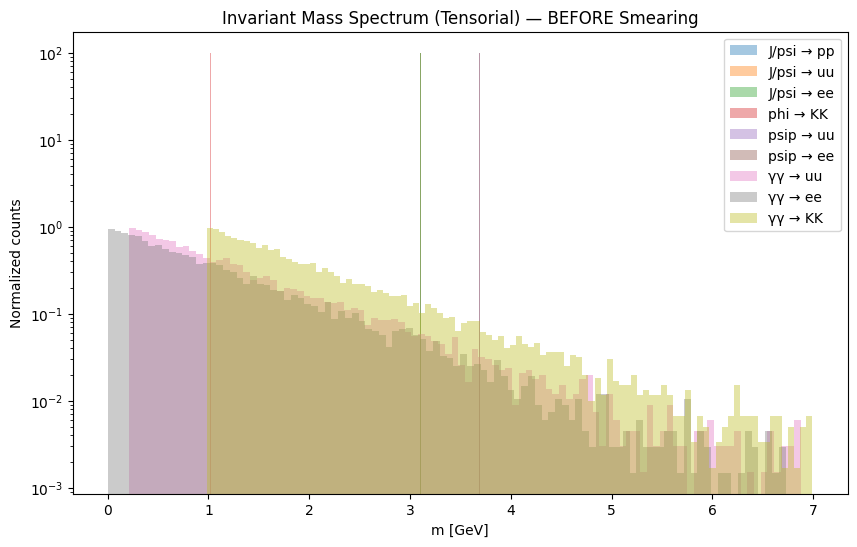

In [12]:
plt.figure(figsize=(10,6))

for name, masses in data_raw1.items():
    plt.hist(masses, bins=100, alpha=0.4, label=name, density=True)

plt.title("Invariant Mass Spectrum (Tensorial) — BEFORE Smearing")
plt.xlabel("m [GeV]")
plt.yscale("log")
plt.ylabel("Normalized counts")
plt.legend()
plt.show()

In [13]:
def smear_event(v, sigma_E=0.02, sigma_p=0.02, sigma_ang=0.001):
    """
    Smear a single event: [E, p, theta, phi]
    """

    E, p, th, ph = v

    # energy and momentum magnitude smearing (Gaussian, fractional)
    E_s = E * np.random.normal(1.0, sigma_E)
    p_s = p * np.random.normal(1.0, sigma_p)

    # angular smearing
    th_s = th + np.random.normal(0.0, sigma_ang)
    ph_s = ph + np.random.normal(0.0, sigma_ang)

    # keep angles physical
    th_s = np.clip(th_s, 0.0, np.pi)
    ph_s = ph_s % (2 * np.pi)

    return np.array([E_s, p_s, th_s, ph_s])

In [14]:
def smear_event_momentum_only(v, mass=0.0, sigma_p=0.02):
    """
    Momentum-based smearing only.

    v = [E, p, theta, phi]
    mass = particle mass (set 0 for ultra-relativistic approximation)
    """

    E, p, th, ph = v

    # convert spherical -> Cartesian momentum
    px = p * np.sin(th) * np.cos(ph)
    py = p * np.sin(th) * np.sin(ph)
    pz = p * np.cos(th)

    p_vec = np.array([px, py, pz])

    # smear each momentum component
    p_vec_s = p_vec * (1.0 + np.random.normal(0.0, sigma_p, size=3))

    # recompute momentum magnitude
    p_s = np.linalg.norm(p_vec_s)

    # avoid division issues
    if p_s == 0:
        return np.array([0.0, 0.0, th, ph])

    # recompute angles
    th_s = np.arccos(np.clip(p_vec_s[2] / p_s, -1.0, 1.0))
    ph_s = np.arctan2(p_vec_s[1], p_vec_s[0])

    # reconstruct energy consistently
    E_s = np.sqrt(p_s**2 + mass**2)

    return np.array([E_s, p_s, th_s, ph_s])

In [15]:
def smear_event_resolution(v, a=0.01, b=0.001):
    """
    Resolution-driven smearing:
    dp/p = a + b p

    v = [E, p, theta, phi]
    """

    E, p, th, ph, m = v

    # resolution
    sigma_p = p * (a + b * p)

    # smear momentum magnitude
    p_s = np.random.normal(p, sigma_p)

    # enforce positivity
    p_s = max(p_s, 0.0)

    # angles unchanged (simple detector model)
    th_s = th
    ph_s = ph

    # reconstruct energy (massless approximation)
    E_s = p_s

    return np.array([E_s, p_s, th_s, ph_s, m])

In [16]:
def smear_event_resolution(v, a=0.01, b=0.001):

    E, p, th, ph, m = v

    sigma_p = p * (a + b * p)

    p_s = np.random.normal(p, sigma_p)
    p_s = max(p_s, 0.0)

    th_s = th
    ph_s = ph

    # correct energy reconstruction
    E_s = np.sqrt(p_s**2 + m**2)

    return np.array([E_s, p_s, th_s, ph_s, m])

In [17]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        # apply detector smearing AFTER generation
        if smear:
            # v1 = smear_event_momentum_only(v1)
            # v2 = smear_event_momentum_only(v2)

            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [18]:
data_raw2 = {
    name: sample_process(gen, N=10000, smear=False)
    for name, gen in processes.items()
}

In [19]:
data_smeared = {
    name: sample_process(gen, N=10000, smear=True)
    for name, gen in processes.items()
}

In [20]:
def plot_raw_vs_smeared(data_raw, data_smeared, bins=120):
    """
    For each process, plot raw vs smeared invariant mass distributions.
    """
    for name in data_raw.keys():
        raw = data_raw[name]
        smeared = data_smeared[name]

        plt.figure(figsize=(8, 5))

        # Histogram of raw data
        plt.hist(
            raw, bins=bins, density=True, alpha=0.6,
            label=f"{name} (raw)", color="blue"
        )

        # Histogram of smeared data
        plt.hist(
            smeared, bins=bins, density=True, alpha=0.6,
            label=f"{name} (smeared)", color="red"
        )

        # Labels and title
        plt.title(f"Invariant Mass Distribution: {name}")
        plt.xlabel("Invariant Mass [GeV]")
        plt.ylabel("Normalized Counts")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


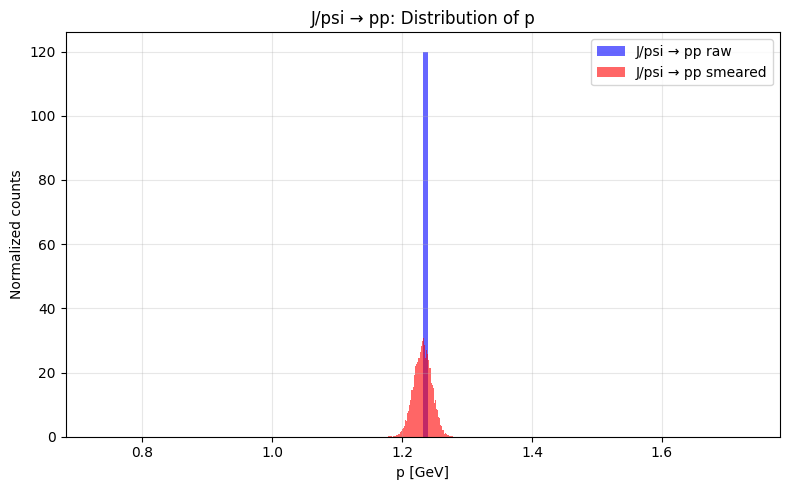

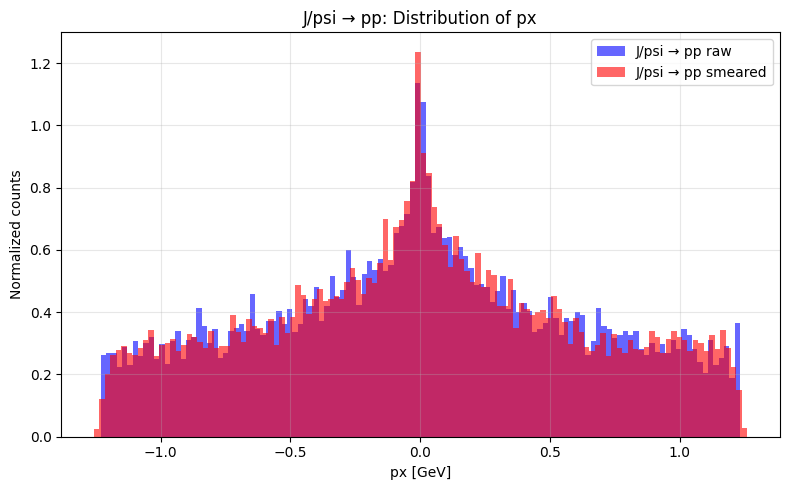

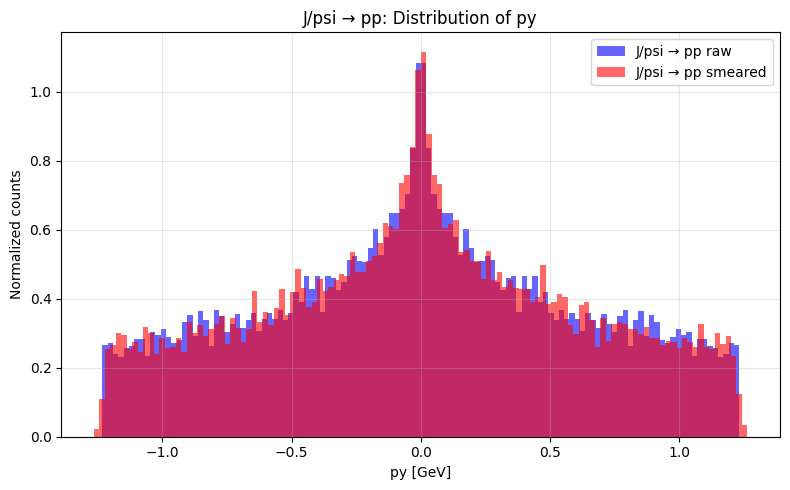

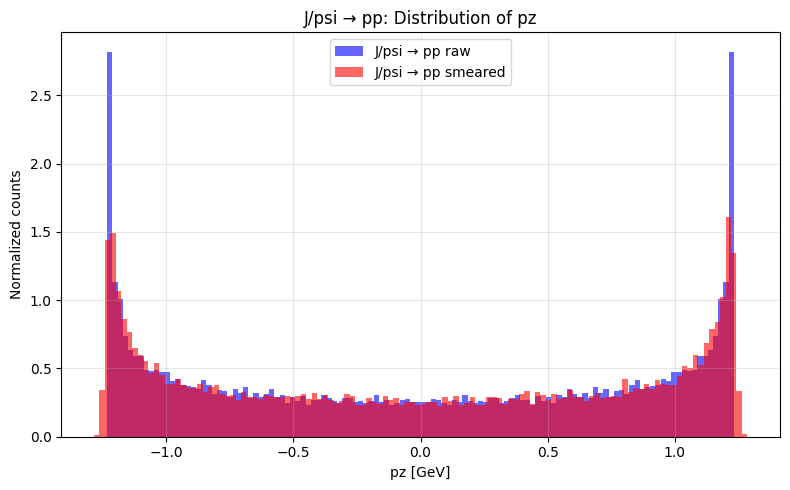

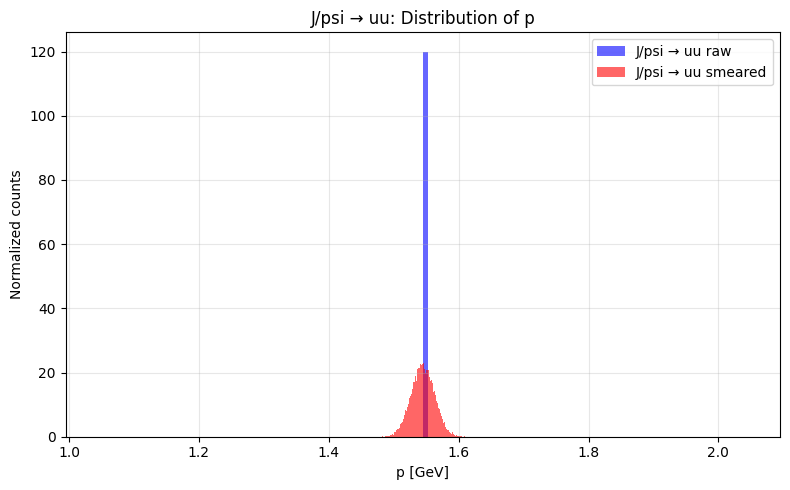

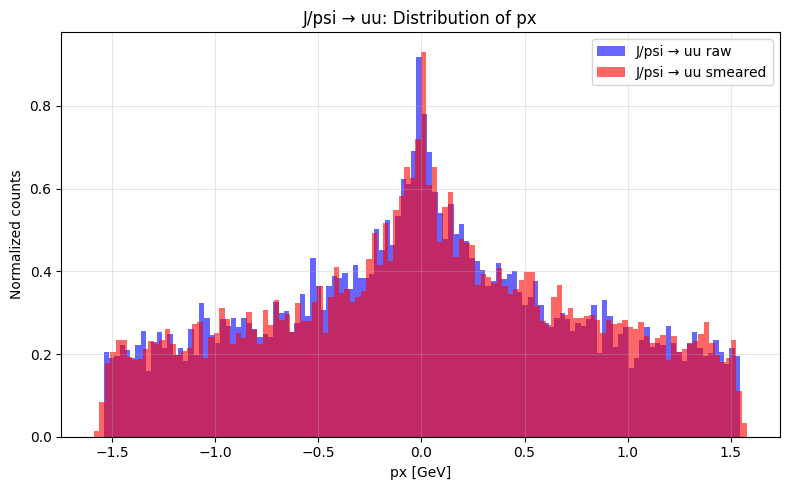

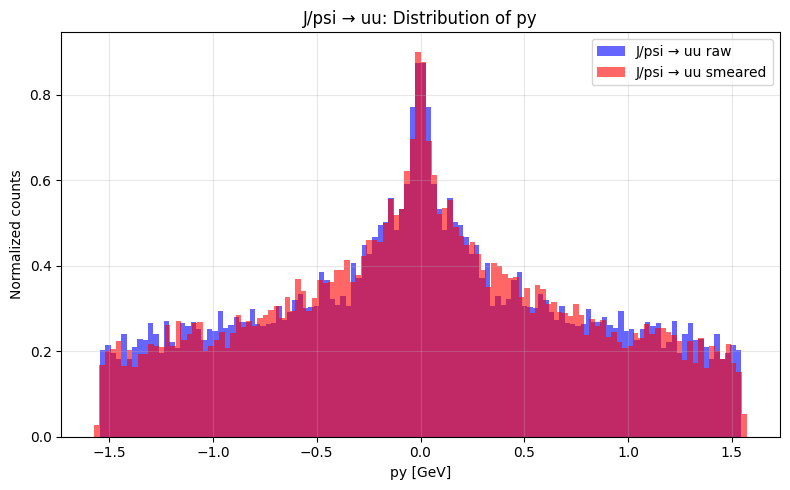

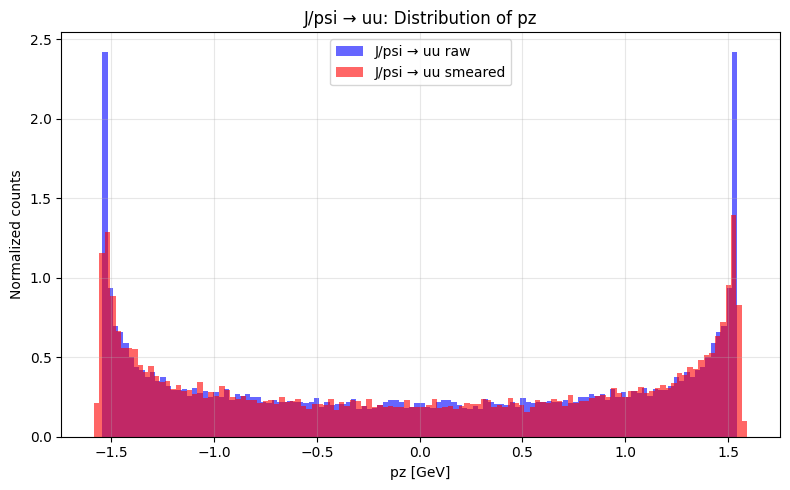

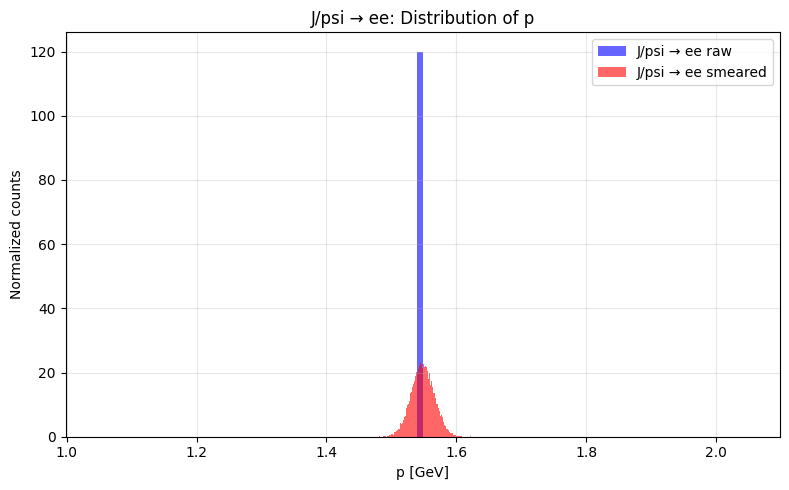

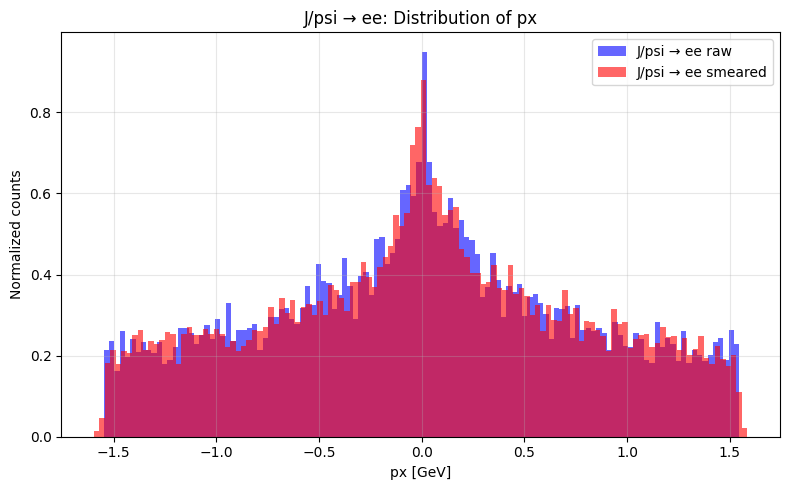

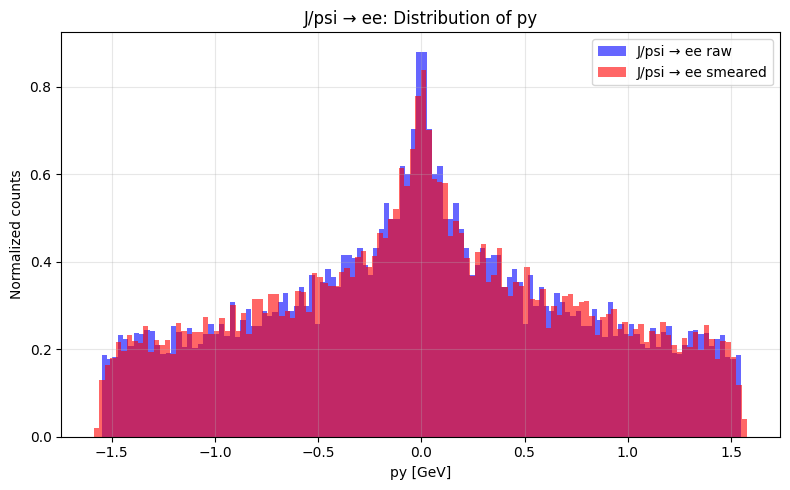

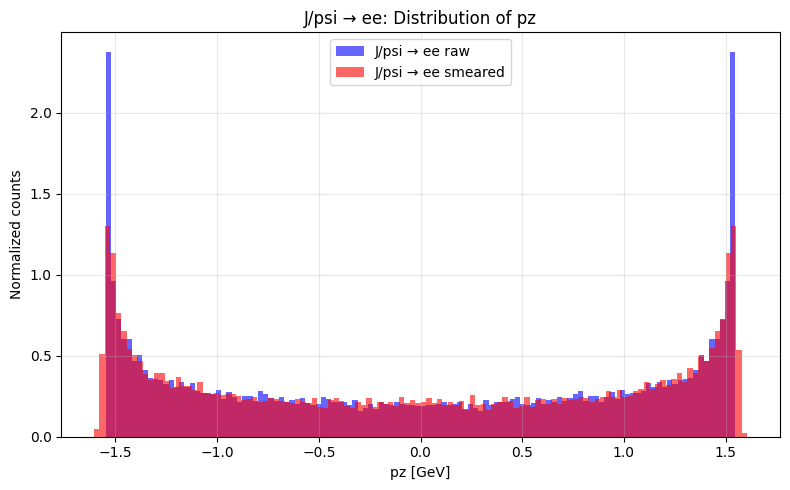

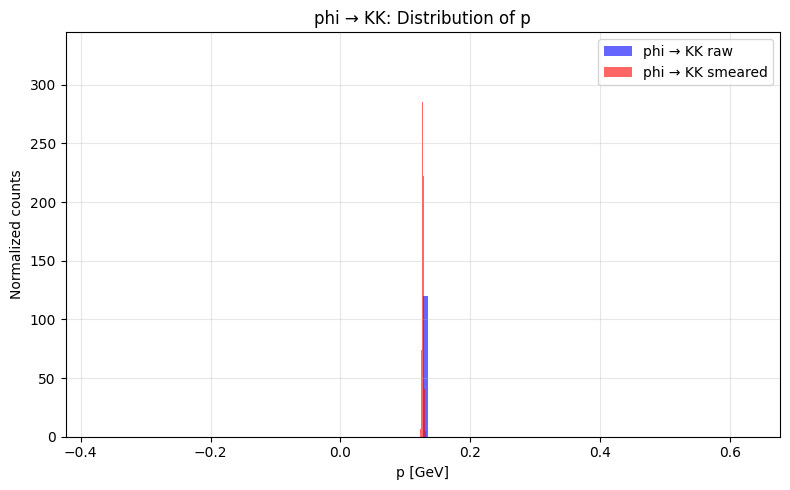

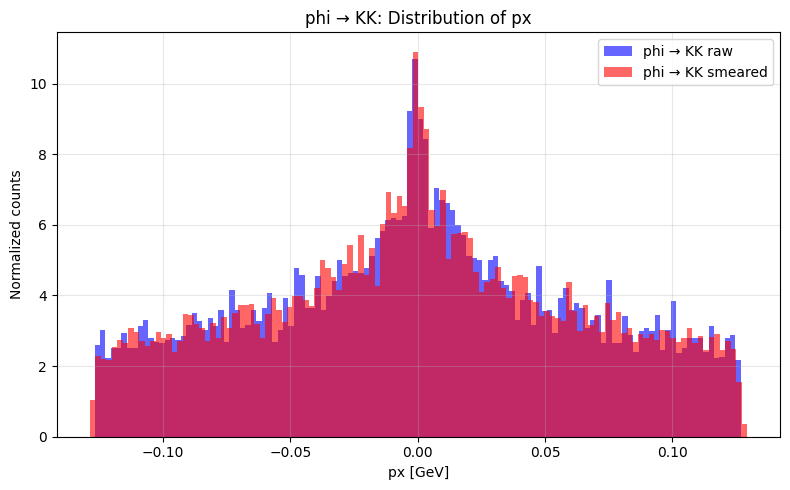

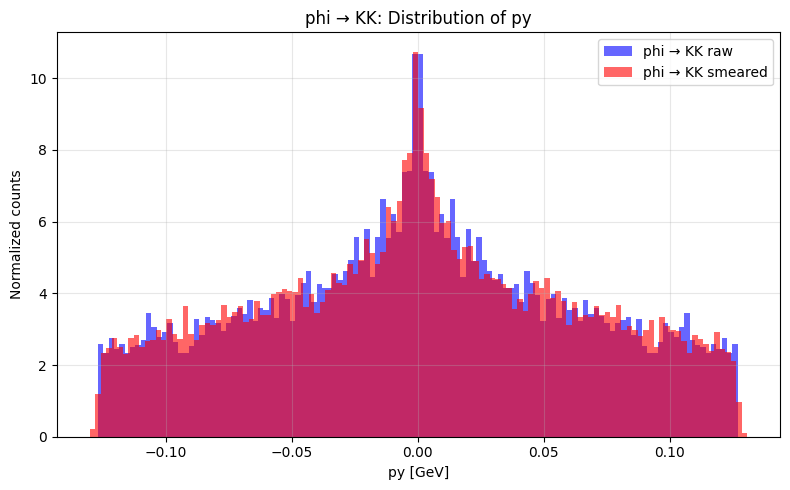

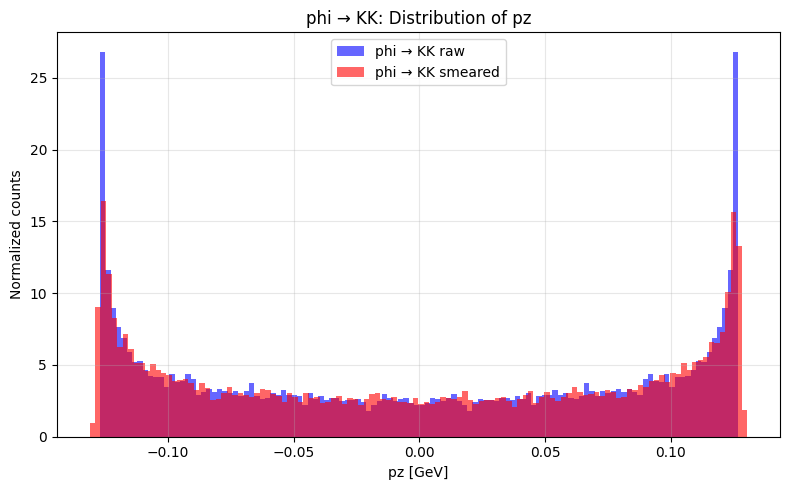

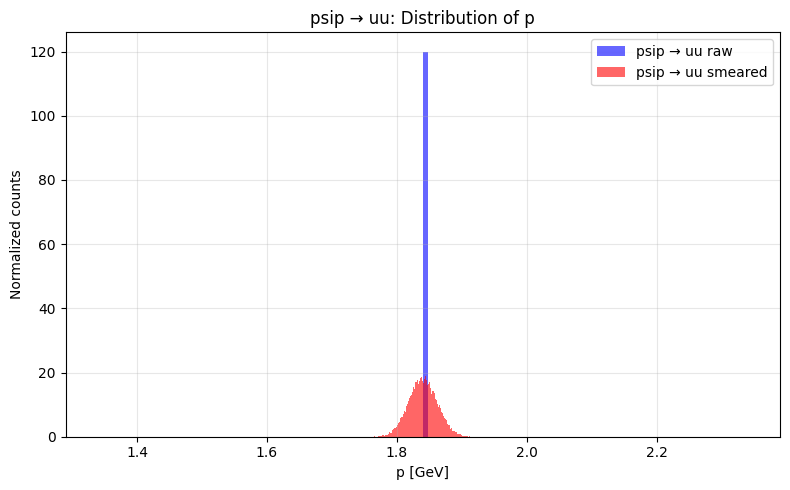

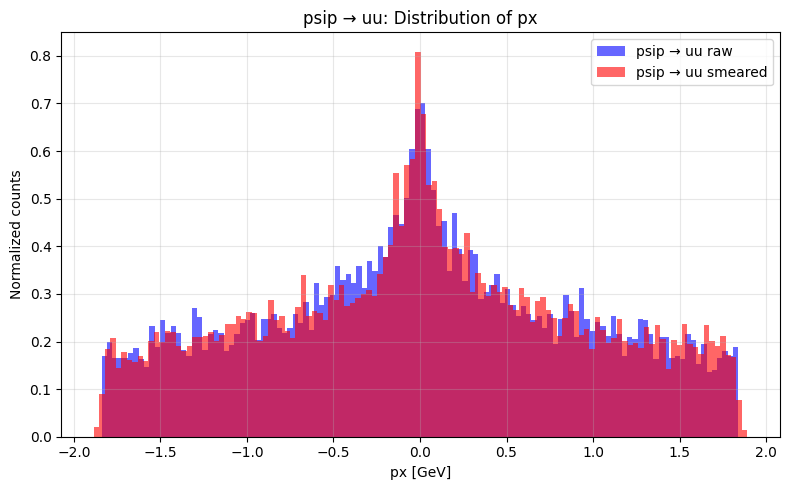

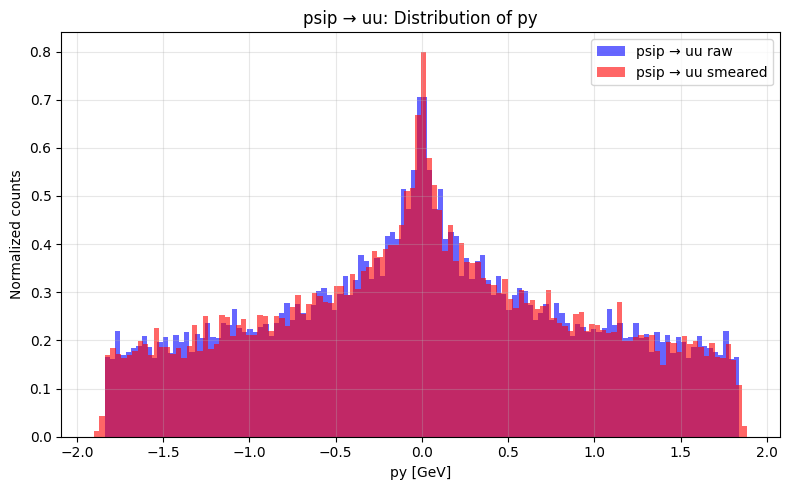

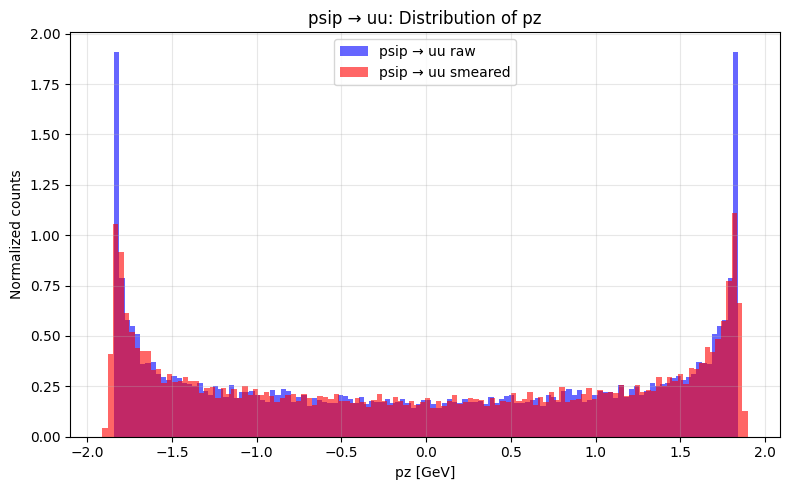

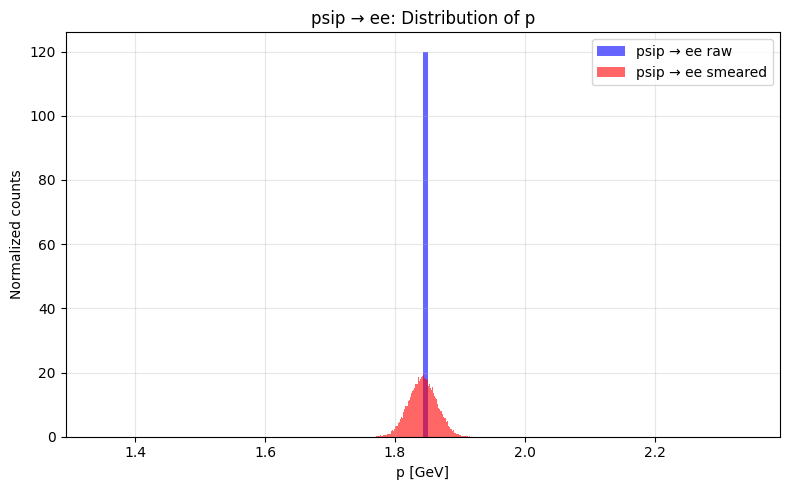

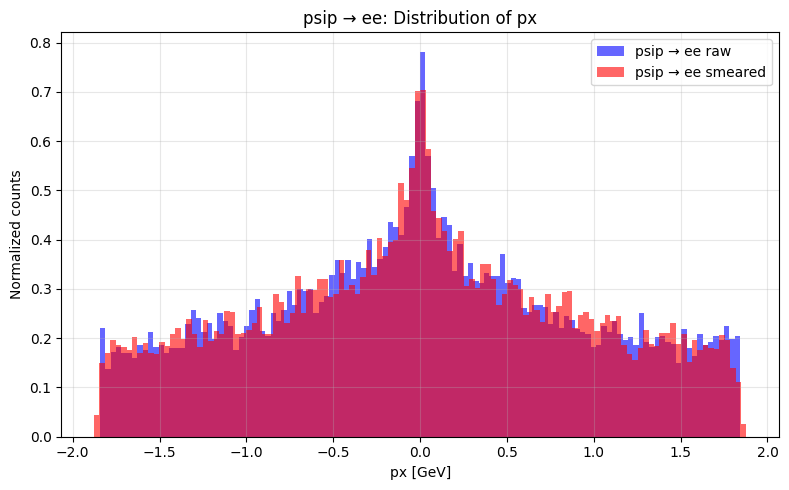

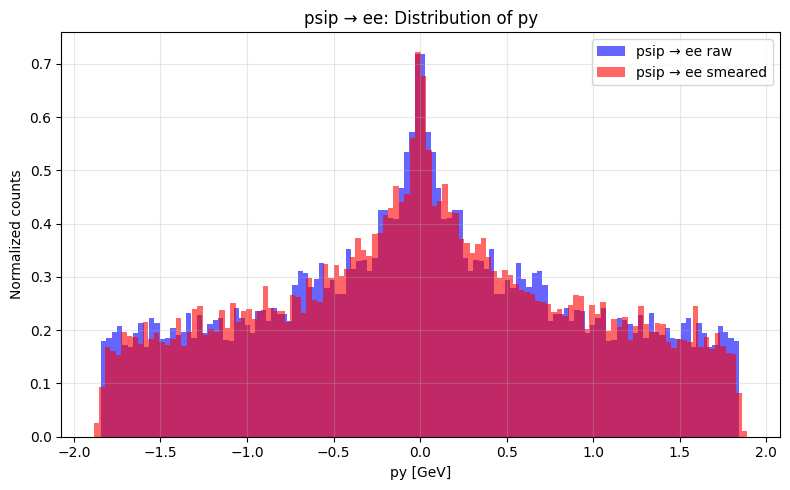

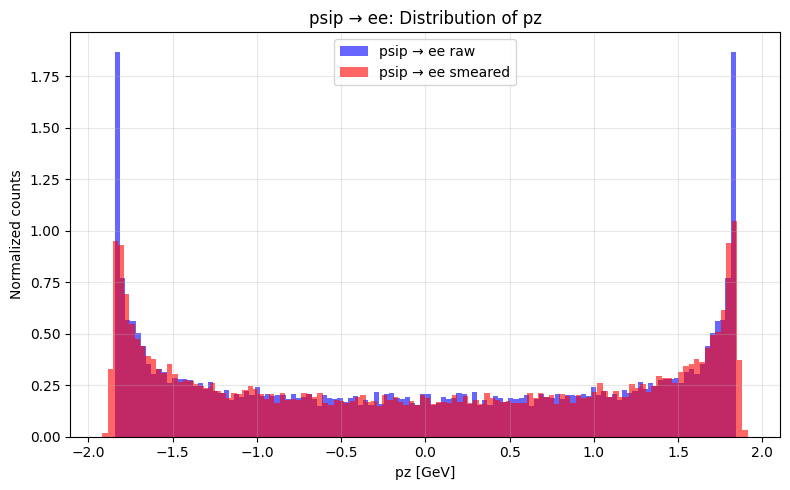

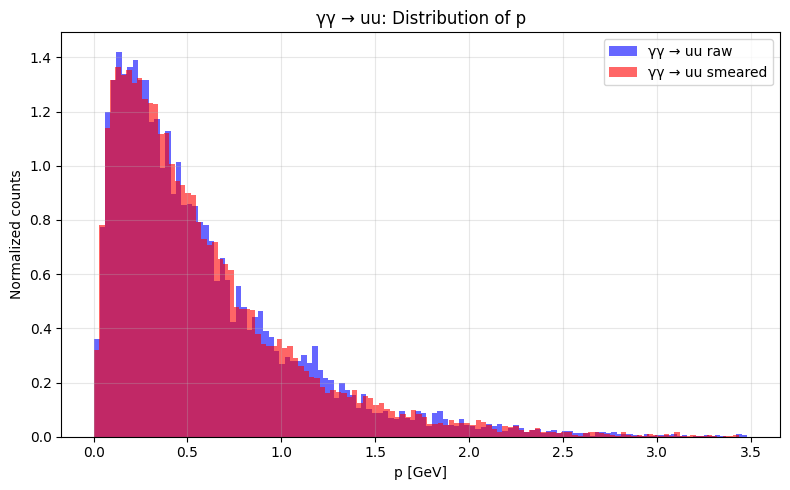

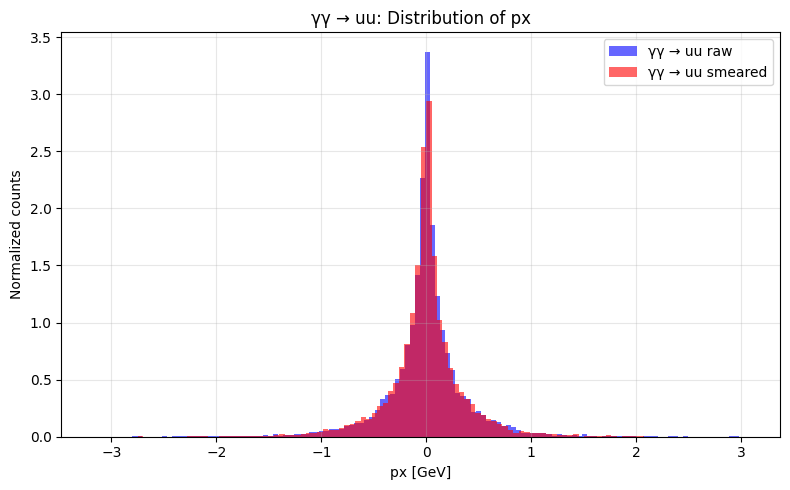

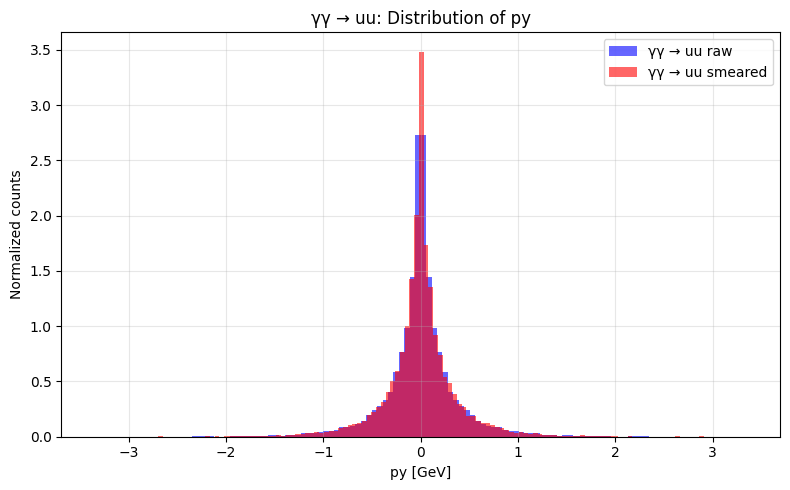

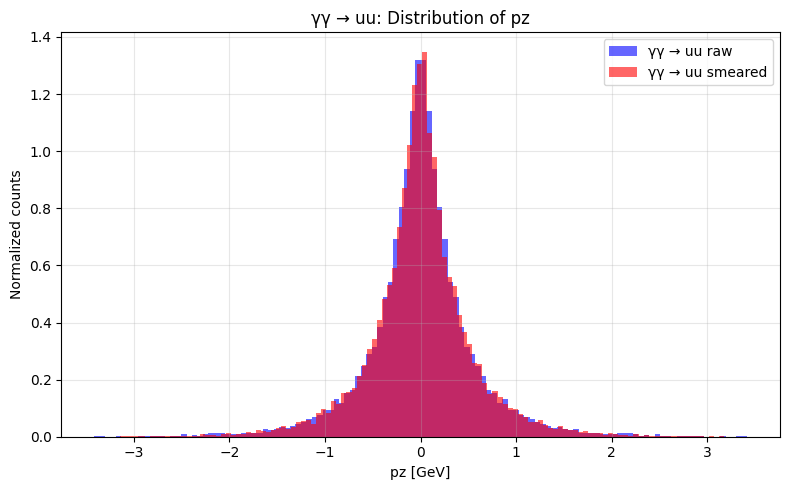

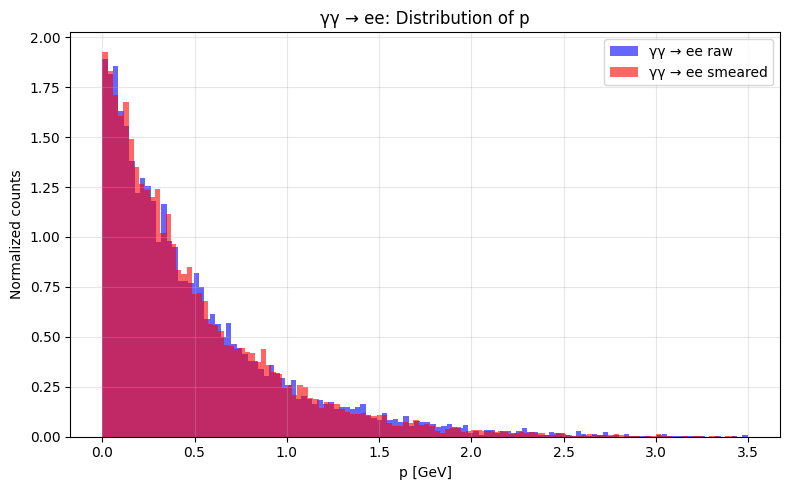

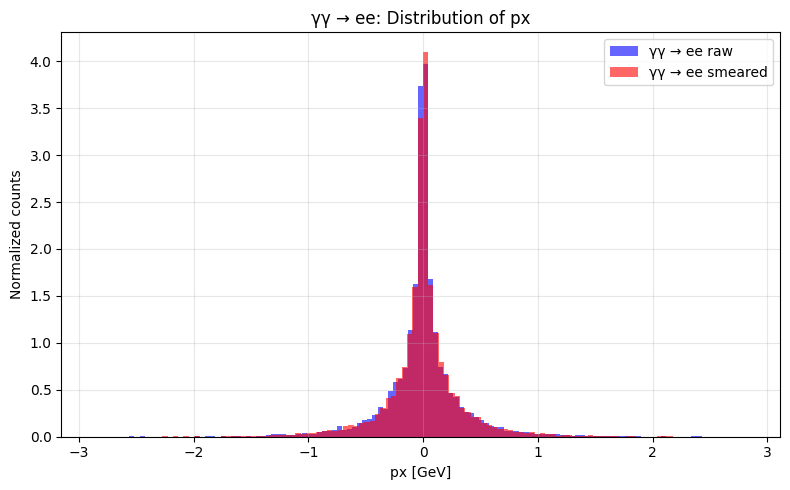

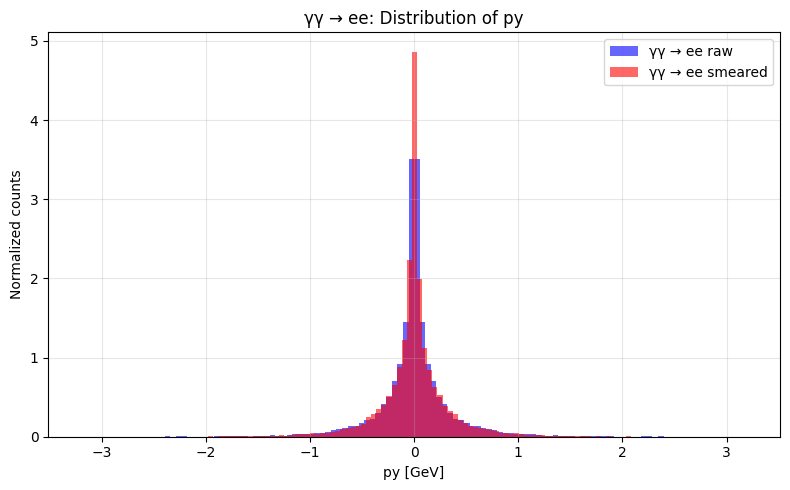

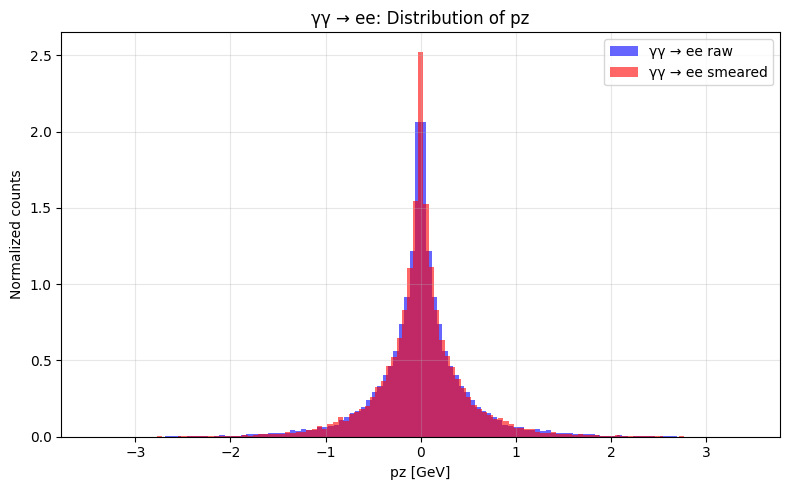

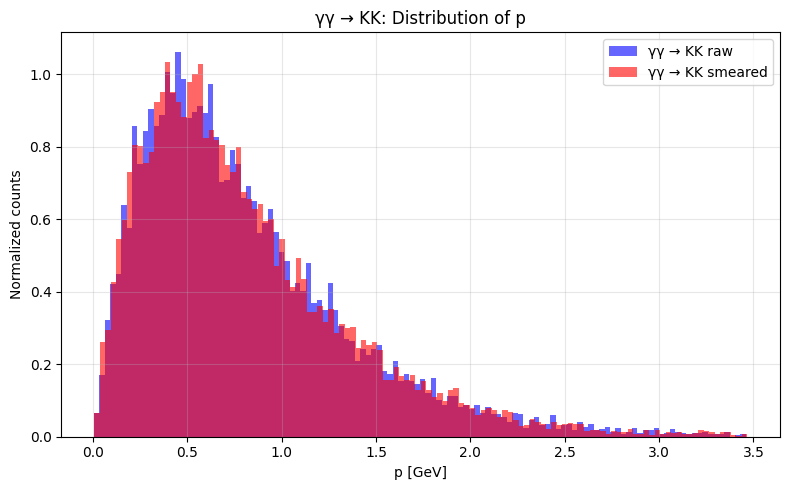

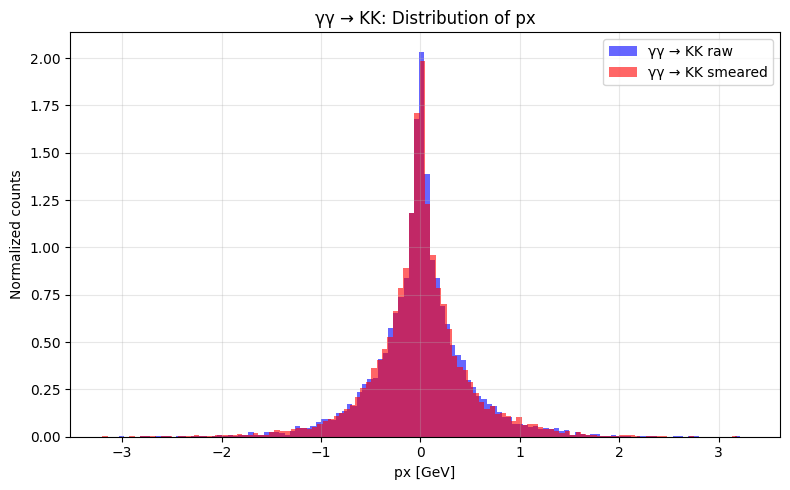

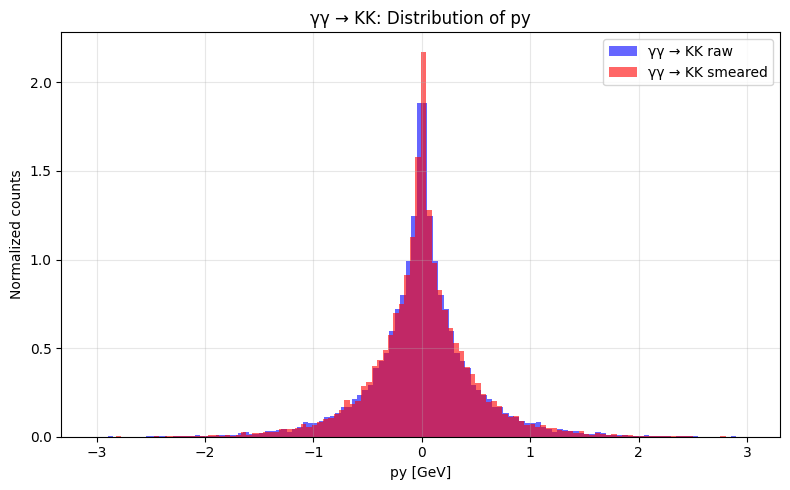

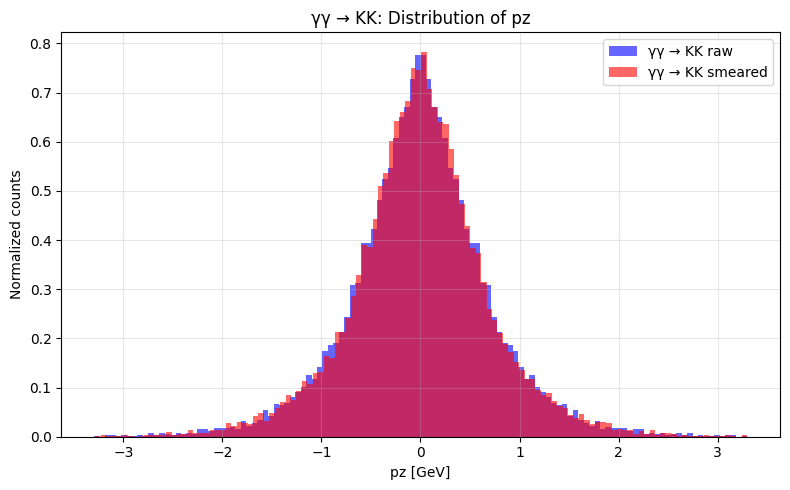

In [21]:
def extract_momentum_components(v):
    """
    v = [E, p, theta, phi, m]
    Returns (p, px, py, pz)
    """
    E, p, th, ph, m = v
    px = p * np.sin(th) * np.cos(ph)
    py = p * np.sin(th) * np.sin(ph)
    pz = p * np.cos(th)
    return p, px, py, pz


def sample_momentum(generator, N=20000, smear=False):
    """
    Collect momentum magnitudes for single tracks.
    Returns arrays for p1, p2.
    """
    p_list = []
    px_list = []
    py_list = []
    pz_list = []

    for _ in range(N):
        v1, v2 = generator()

        if smear:
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)

        # extract momentum components
        for v in (v1, v2):
            p, px, py, pz = extract_momentum_components(v)
            p_list.append(p)
            px_list.append(px)
            py_list.append(py)
            pz_list.append(pz)

    return {
        "p": np.array(p_list),
        "px": np.array(px_list),
        "py": np.array(py_list),
        "pz": np.array(pz_list),
    }


def plot_momentum_distributions(momentum_raw, momentum_smeared, name, bins=120):
    """
    Plot raw vs smeared momentum distributions for a single process.
    """
    for comp in ["p", "px", "py", "pz"]:
        plt.figure(figsize=(8,5))

        plt.hist(momentum_raw[comp], bins=bins, density=True,
                 alpha=0.6, label=f"{name} raw", color="blue")

        plt.hist(momentum_smeared[comp], bins=bins, density=True,
                 alpha=0.6, label=f"{name} smeared", color="red")

        plt.title(f"{name}: Distribution of {comp}")
        plt.xlabel(f"{comp} [GeV]")
        plt.ylabel("Normalized counts")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


# --- RUN FOR ALL PROCESSES ---

momentum_raw_all = {
    name: sample_momentum(gen, N=10000, smear=False)
    for name, gen in processes.items()
}

momentum_smeared_all = {
    name: sample_momentum(gen, N=10000, smear=True)
    for name, gen in processes.items()
}

# Plot for each process
for name in processes.keys():
    plot_momentum_distributions(momentum_raw_all[name],
                                momentum_smeared_all[name],
                                name)

# momentum of single tracks

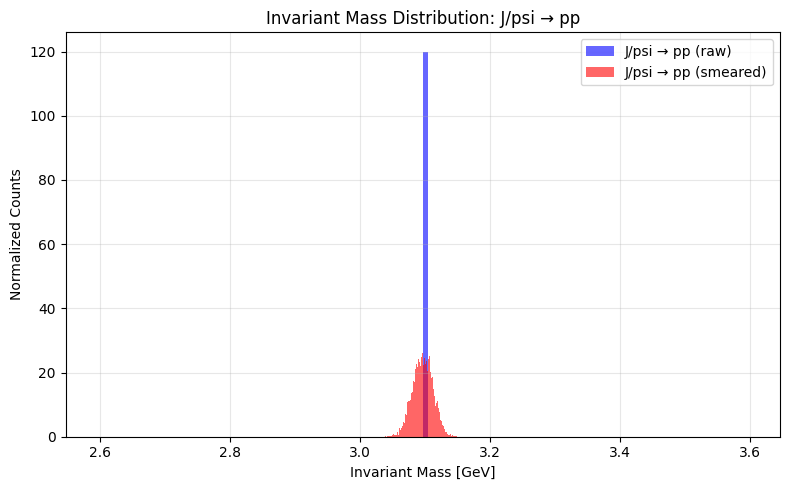

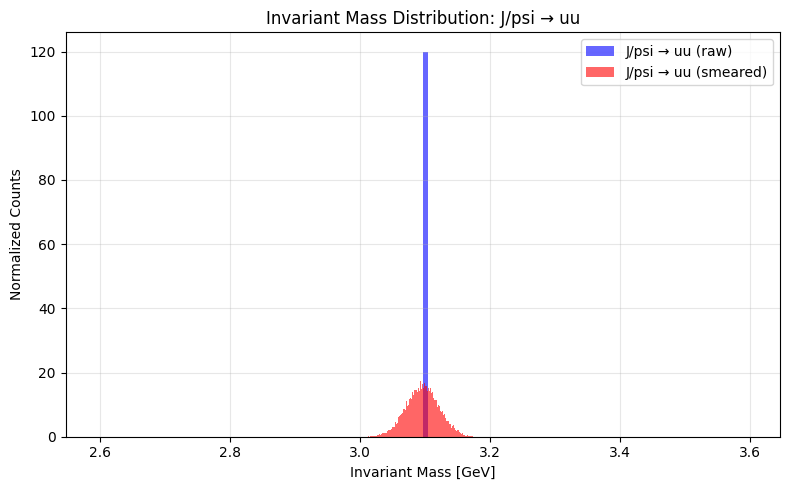

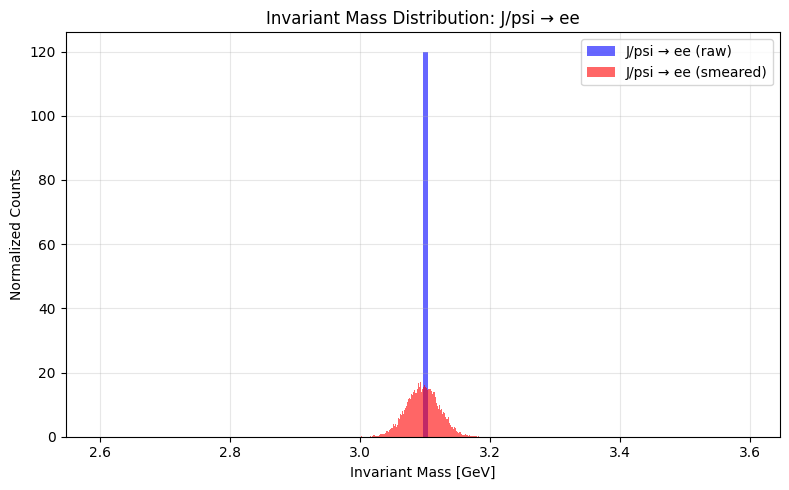

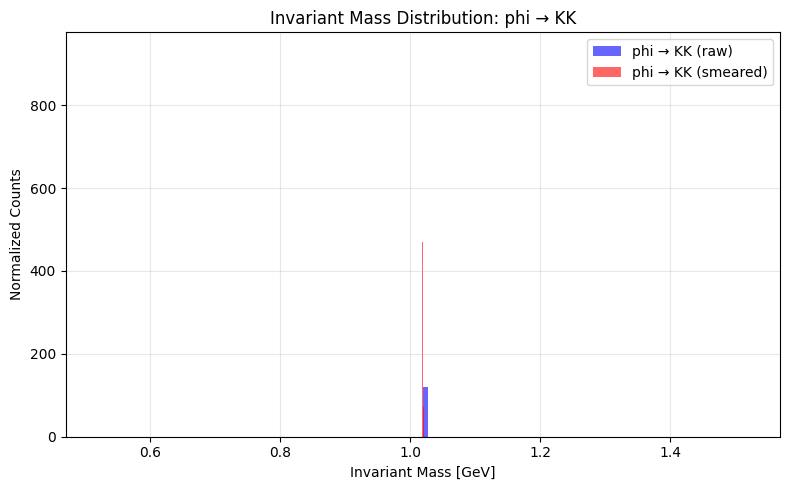

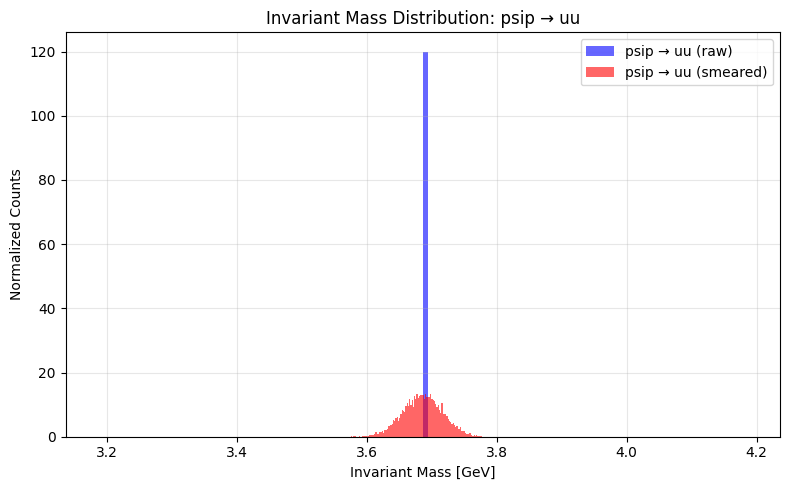

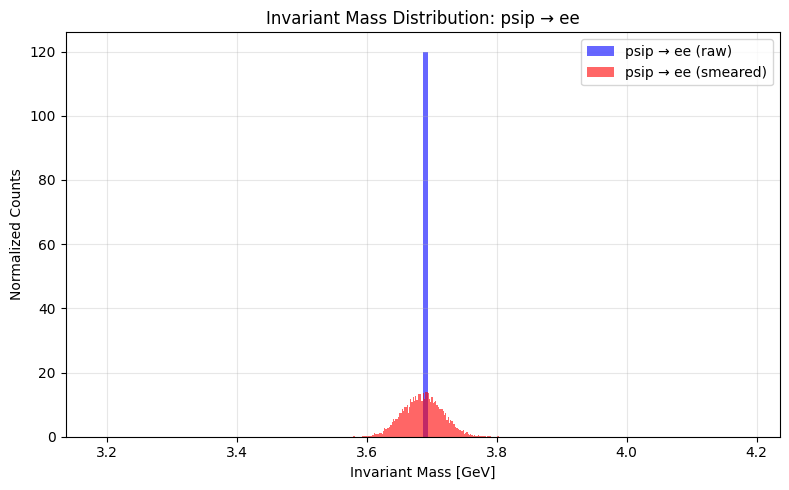

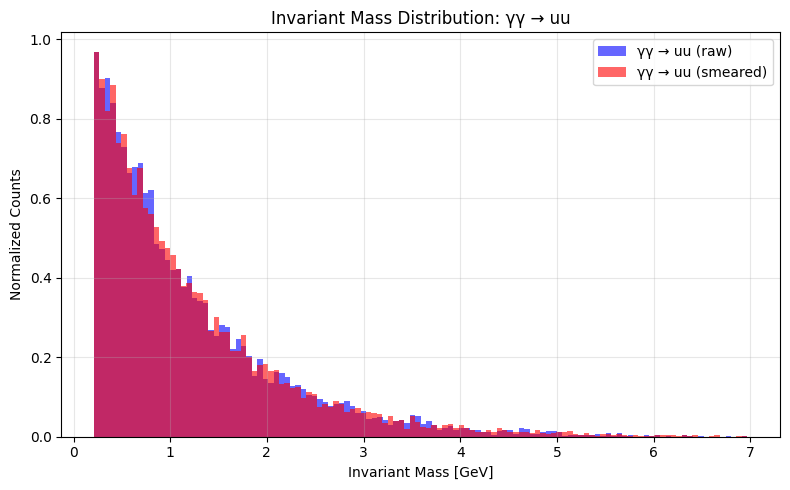

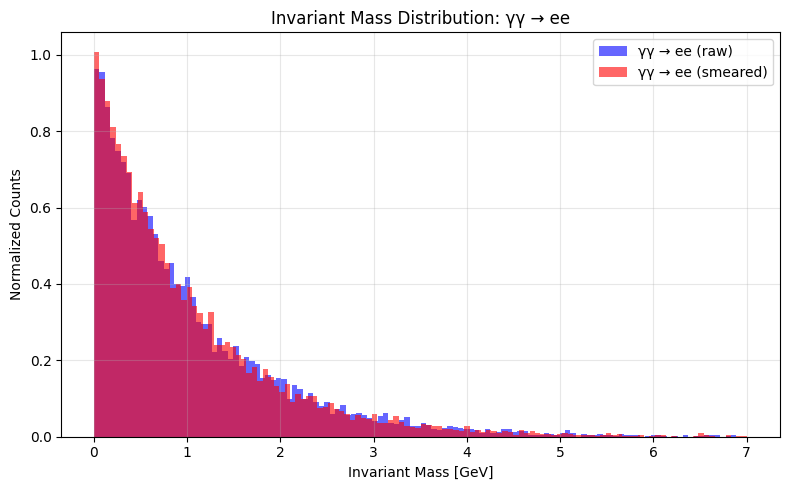

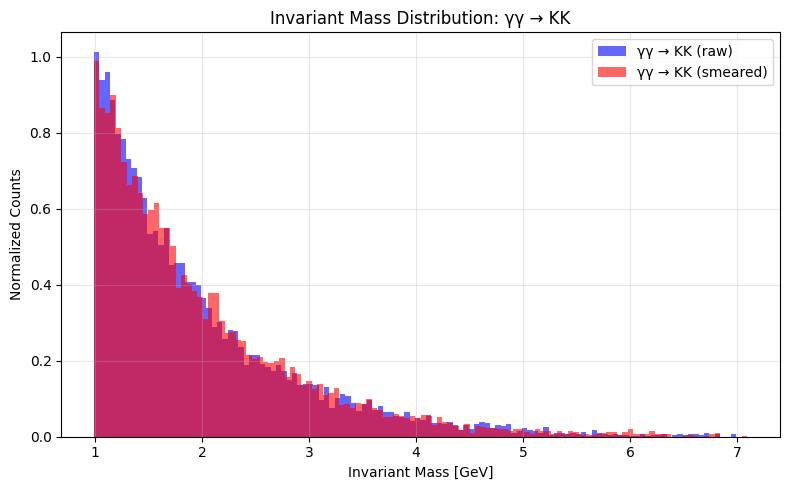

In [22]:
plot_raw_vs_smeared(data_raw2, data_smeared)

In [23]:
def plot_only_smeared(data_smeared, bins=100):
    plt.figure(figsize=(10,6))

    for name, masses in data_smeared.items():
        plt.hist(
            masses,
            bins=bins,
            histtype='step',
            density=True,
            linewidth=1.5,
            label=name
        )

    plt.xlabel("Invariant mass [GeV]")
    plt.ylabel("Normalized counts")
    plt.title("Smeared Invariant Mass Distributions")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

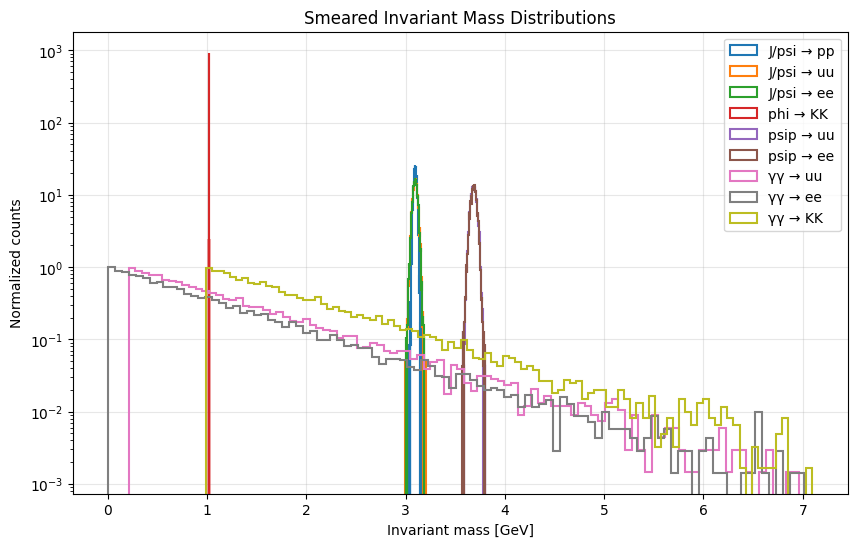

In [24]:
plot_only_smeared(data_smeared)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def bethe_bloch(momentum, mass, charge=1):
# Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

# Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

# Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx


In [26]:
momentum = .3 # Example momentum in GeV/c
particle_type = 'proton' # Example particle type
x=1000 #Amount of random numbers

rn=[]
for _ in range(x):

    if (particle_type == 'electron'):
        stretch_factor=1
    elif (particle_type == 'muon'):
        stretch_factor=.41
    elif (particle_type == 'pion'):
        stretch_factor=.41
    elif (particle_type == 'kaon'):
        stretch_factor=.38
    elif (particle_type == 'proton'):
        stretch_factor=.40

random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
rn.append(random_value)

print(rn)

xvalues=[]
for _ in range(x):
    xvalues.append(momentum)
    print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
    'Electron': {'color': 'blue', 'stretch_factor': 1},
    'Muon': {'color': 'orange', 'stretch_factor': 0.41},
    'Pion': {'color': 'red', 'stretch_factor': 0.41},
    'Kaon': {'color': 'green', 'stretch_factor': 0.38},
    'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }


    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

    # plt.plot(xvalues,rn, color= 'black')

    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')  # Log scale for x-axis
    plt.yscale('log')  # Log scale for y-axis
    plt.title('ALICE TPC PID Response with 3sigma Bands')
    plt.legend()
    plt.grid(True)
    plt.show


[214.09011636172406]
[0.3]
[0.3, 0.3]
[0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3,

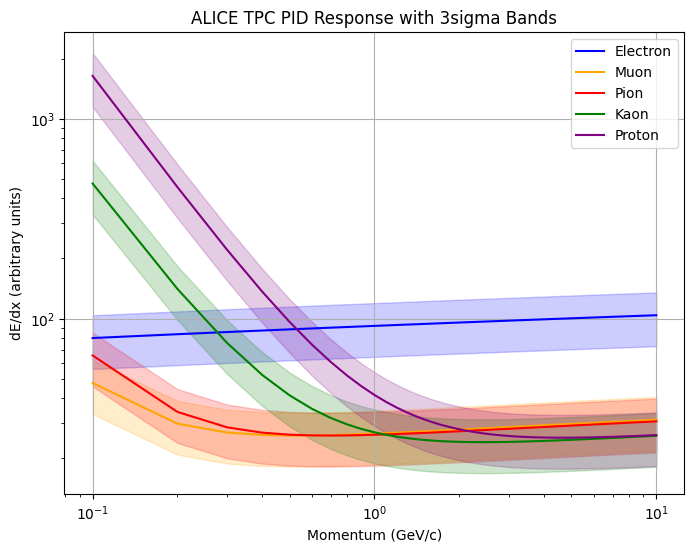

In [27]:

momentum_range = np.linspace(0.1, 10, 100) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)




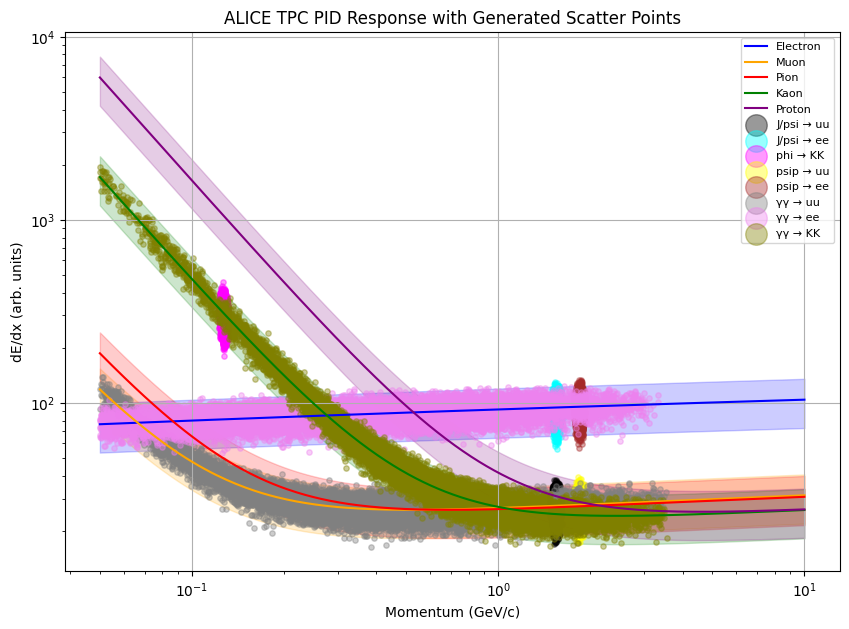

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
#  BETHE–BLOCH + TPC RESPONSE
# ============================================================

def bethe_bloch(momentum, mass, charge=1):
    K = 0.307075
    Z = charge
    I = 0.000016
    m_e = 0.511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    dEdx = ((K * Z**2 * rho) / (beta**2) *
            (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx


def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3
    return dEdx, lower_band, upper_band


def error_extremes(momentum, particle_type, stretch_factor):
    _, low, up = tpc_pid_response(momentum, particle_type, stretch_factor)
    return up, low


def random_gaussian(mean, sigma):
    return np.random.normal(mean, sigma)


def gaussian_tpc_response(momentum, particle_type, stretch_factor):
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type, stretch_factor)
    upper, lower = error_extremes(momentum, particle_type, stretch_factor)
    sigma = (upper - lower) / 6
    return random_gaussian(mean_dEdx, sigma)


# ============================================================
#  PROCESS DICTIONARY
# ============================================================

processes = {
#   "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "psip → ee": generate_psip_ee,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

# ============================================================
#  SCATTER POINT GENERATION FOR TPC PLOT
# ============================================================

def particle_type_from_mass(m):
    if abs(m - M_E) < 1e-3: return "electron"
    if abs(m - M_U) < 1e-3: return "muon"
    if abs(m - M_K) < 1e-3: return "kaon"
    if abs(m - M_P) < 1e-3: return "proton"
    return "pion"


def stretch_factor_for(particle):
    return {
        "electron": 1,
        "muon": 0.41,
        "pion": 0.41,
        "kaon": 0.38,
        "proton": 0.40
    }[particle]

vectors_list = []
def generate_scatter_points(generator, momentum_range, N=2000):
    momenta = []
    dEdx_vals = []

    minval = min(momentum_range)
    maxval = max(momentum_range)
    for _ in range(N):
        v1, v2 = generator()
        v1 = smear_event_resolution(v1)
        v2 = smear_event_resolution(v2)
        vectors_list.append((v1,v2))
        for v in (v1, v2):
            E, p, th, ph, m = v
            if p < minval:
                continue
            if p > maxval:
                continue
            particle = particle_type_from_mass(m)
            sf = stretch_factor_for(particle)

            dEdx = gaussian_tpc_response(p, particle, sf)

            momenta.append(p)
            dEdx_vals.append(dEdx)

    return np.array(momenta), np.array(dEdx_vals)


# ============================================================
#  PLOTTER
# ============================================================

def plot_tpc_with_scatter(momenta_range):
    momentum_range = momenta_range

    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(10, 7))

    # PID bands
    for particle, settings in particle_types.items():
        resp, low, up = tpc_pid_response(
            momentum_range, particle.lower(), settings['stretch_factor']
        )
        plt.plot(momentum_range, resp, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, low, up, color=settings['color'], alpha=0.2)

    # Scatter points from generators
    colors = ["black", "cyan", "magenta", "yellow", "brown", "gray", "violet", "olive", "red"]

    for (name, gen), col in zip(processes.items(), colors):
        pvals, dvals = generate_scatter_points(gen, momentum_range, N=10000)
        plt.scatter(pvals, dvals, s=15, alpha=0.4, label=name, color=col)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("dE/dx (arb. units)")
    plt.title("ALICE TPC PID Response with Generated Scatter Points")
    plt.legend(markerscale=4, fontsize=8)
    plt.grid(True)
    plt.show()


# ============================================================
#  RUN
# ============================================================
momentum_range = np.linspace(0.05, 10, 2000)
plot_tpc_with_scatter(momentum_range)


In [29]:
def spherical_to_cartesian(v):
    E, p, theta, phi, m = v
    px = p * np.sin(phi) * np.cos(theta)
    py = p * np.sin(phi) * np.sin(theta)
    pz = p * np.cos(phi)
    return np.array([E, px, py, pz, m])


def cartesian_to_spherical(v):
    E, px, py, pz, m = v
    p = np.sqrt(px**2 + py**2 + pz**2)
    if p > 0:
        theta = np.arctan2(py, px)
        if theta < 0:
            theta += 2*np.pi
        phi = np.arccos(pz / p)
    else:
        theta = 0
        phi = 0
    return np.array([E, p, theta, phi, m])

In [30]:
def invariant_mass_PENTA(vectors):
    total = np.zeros(4)

    for v in vectors:
        cart = spherical_to_cartesian(v)   # [E, px, py, pz, m]
        total += cart[:4]                  # use only the first 4 components

    E, px, py, pz = total
    M2 = E*E - (px*px + py*py + pz*pz)
    return np.sqrt(max(M2, 0.0))


In [31]:
import numpy as np
import pandas as pd


# ============================================================
#  TABLE GENERATOR
# ============================================================

def generate_pid_table():
    rows = []

    species = ["electron", "muon", "pion", "kaon", "proton"]
    i=0
    for _ in vectors_list:
        if len(_) == 2:
           mass = invariant_mass(_[0], _[1])
        elif len(_) == 3:
           mass = invariant_mass_PENTA(_)
        for v in _:
            E, p, theta, phi, m = v
            px = p * np.sin(phi) * np.cos(theta)
            py = p * np.sin(phi) * np.sin(theta)
            pz = p * np.cos(phi)

            v = np.array([E, px, py, pz, m])
            
            #if p < 0.1:
            #    continue

            ptype = particle_type_from_mass(m)
            sf = stretch_factor_for(ptype)

            dEdx_meas = gaussian_tpc_response(p, ptype, sf)

            # compute Nσ for each species
            nsig = {}
            for sp in species:
                mean, low, up = tpc_pid_response(p, sp, stretch_factor_for(sp))
                sigma = (up - low) / 6
                nsig[sp] = (dEdx_meas - mean) / sigma

            rows.append({
                "EvID": i,
                "ptype": ptype,
                "px": px,
                "py": py,
                "pz": pz,
                "p": p,
                "E": E,
                "dEdx_meas": dEdx_meas,
                **{f"nsigma_{sp}": nsig[sp] for sp in species},
                "Invariant mass": mass
            })
        i+=1

    return pd.DataFrame(rows)


# ============================================================
#  RUN EXAMPLE
# ============================================================

df = generate_pid_table()
df.tail()


,EvID,ptype,px,py,pz,p,E,dEdx_meas,nsigma_electron,nsigma_muon,nsigma_pion,nsigma_kaon,nsigma_proton,Invariant mass
159995,79997,kaon,0.394356,-0.512265,0.196645,0.675723,0.836850,26.672845,-7.036438,0.193970,0.240129,-1.818801,-5.798816,1.676297
159996,79998,kaon,0.412266,-1.466736,1.400976,2.069785,2.127846,27.690260,-7.110972,-0.097856,0.097185,1.444030,-0.013666,4.281426
159997,79998,kaon,-0.417550,1.485537,-1.418934,2.096317,2.153662,23.915568,-7.506529,-1.455450,-1.286878,-0.112416,-1.345048,4.281426
159998,79999,kaon,0.106005,-0.361066,0.035139,0.377943,0.621738,66.650814,-2.336308,15.334387,14.533200,1.918593,-5.546163,1.245464
159999,79999,kaon,-0.106922,0.364191,-0.035443,0.381213,0.623731,57.937652,-3.341615,12.035338,11.356808,0.468690,-6.073210,1.245464


In [32]:
# ============================================================
# EVENT-LEVEL PID CANDIDATE TABLE
# ============================================================

def generate_event_candidate_table(df, nsigma_ref=0.5):

    rows = []

    species = ["electron", "muon", "pion", "kaon", "proton"]

    # group tracks by event
    grouped = df.groupby("EvID")

    for ev_id, g in grouped:
        
        row = {"EvID": ev_id}
        
        # ----------------------------------------------------
        # Count candidates for each PID hypothesis
        # ----------------------------------------------------
        for sp in species:

            nsigma_col = f"nsigma_{sp}"

            # A track is a candidate if |Nσ| < Nσ_ref
            n_candidates = np.sum(
                np.abs(g[nsigma_col]) < nsigma_ref
            )

            row[f"N {sp.capitalize()} candidates"] = int(n_candidates)

        # ----------------------------------------------------
        # Total reconstructed tracks
        # ----------------------------------------------------
        row["N Tracks"] = int(len(g))
        row["Invariant Mass"] = g["Invariant mass"].iloc[0]
        rows.append(row)

    return pd.DataFrame(rows)

# ============================================================
#  RUN
# ============================================================

candidate_df = generate_event_candidate_table(df)

candidate_df.tail()

,EvID,N Electron candidates,N Muon candidates,N Pion candidates,N Kaon candidates,N Proton candidates,N Tracks,Invariant Mass
79995,79995,0,0,0,2,0,2,1.119119
79996,79996,0,1,1,1,1,2,4.223141
79997,79997,0,1,1,0,0,2,1.676297
79998,79998,0,1,1,1,1,2,4.281426
79999,79999,0,0,0,1,0,2,1.245464


In [33]:
# ============================================================
# SAVE AS CSV DATASET
# ============================================================

candidate_df.to_csv(
    "event_candidate_dataset_training.csv",
    index=False
)

print("Saved CSV dataset: event_candidate_dataset.csv")

# ============================================================
# SAVE AS PLAIN TEXT FILE
# ============================================================

with open("event_candidate_dataset.txt", "w") as f:

    f.write("ALICE TPC PID EVENT CANDIDATE TABLE\n")
    f.write("=" * 80 + "\n\n")

    f.write(candidate_df.to_string(index=False))

print("Saved text dataset: event_candidate_dataset.txt")

Saved CSV dataset: event_candidate_dataset.csv
Saved text dataset: event_candidate_dataset.txt


In [34]:
import numpy as np
import random

M_PENTA = 4.36

def boost_to_parent(parent4, child4):
    E_p, px_p, py_p, pz_p, _ = parent4
    p_vec = np.array([px_p, py_p, pz_p])
    p_mag = np.linalg.norm(p_vec)

    if p_mag == 0:
        return child4.copy()

    beta = p_mag / E_p
    n = p_vec / p_mag
    gamma = 1.0 / np.sqrt(1 - beta**2)

    E, px, py, pz, m = child4
    p_vec_c = np.array([px, py, pz])

    p_par = np.dot(p_vec_c, n)
    p_perp = p_vec_c - p_par * n

    E_prime = gamma * (E + beta * p_par)
    p_par_prime = gamma * (p_par + beta * E)
    p_prime = p_perp + p_par_prime * n

    return np.array([E_prime, p_prime[0], p_prime[1], p_prime[2], m])


# ----------------- main generator -----------------

def generate_penta_event():
    # penta → J/psi + p
    vJ, vP = generate_two_body(M_PENTA, M_JPSI, M_P)

    J4 = spherical_to_cartesian(vJ)
    P4 = spherical_to_cartesian(vP)

    # J/psi → μ μ (in J/psi rest frame)
    mu1_rest, mu2_rest = generate_Jpsi_uu()

    mu1_4 = spherical_to_cartesian(mu1_rest)
    mu2_4 = spherical_to_cartesian(mu2_rest)

    # boost μ’s to penta rest frame
    mu1_lab = boost_to_parent(J4, mu1_4)
    mu2_lab = boost_to_parent(J4, mu2_4)

    # convert to your (E,p,θ,φ,m) format
    v_mu1 = cartesian_to_spherical(mu1_lab)
    v_mu2 = cartesian_to_spherical(mu2_lab)
    v_p   = cartesian_to_spherical(P4)

    # return ONLY the 3 final tracks
    return v_p, v_mu1, v_mu2


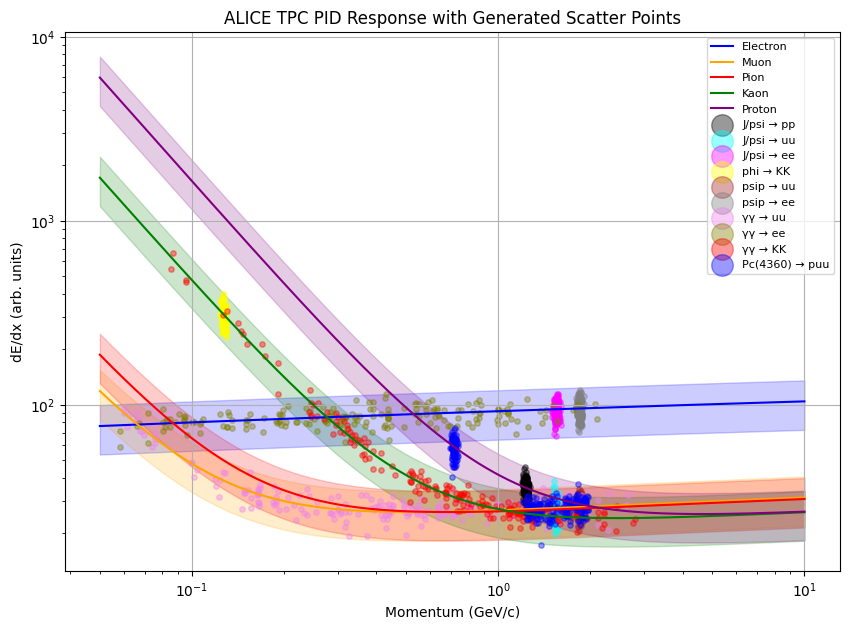

In [35]:
# ============================================================
# REAL DATA SET
# ============================================================

# ============================================================
#  PROCESS DICTIONARY
# ============================================================

processes = {
    "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "psip → ee": generate_psip_ee,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
    "Pc(4360) → puu": generate_penta_event,
}

vectors_list = []
def generate_scatter_points(generator, momentum_range, N=2000):
    momenta = []
    dEdx_vals = []

    minval = min(momentum_range)
    maxval = max(momentum_range)
    for _ in range(N):
        result = generator()
        if len(result) == 2:
            v1, v2 = result
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)
            vectors_list.append((v1,v2))
            vec_res = (v1,v2)
        
        if len(result) == 3:
            v1, v2, v3 = result
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)
            v3 = smear_event_resolution(v3)
            vectors_list.append((v1,v2,v3))
            vec_res = (v1,v2,v3)
        for v in vec_res:
            E, p, th, ph, m = v
            if p < minval:
                continue
            if p > maxval:
                continue
            particle = particle_type_from_mass(m)
            sf = stretch_factor_for(particle)

            dEdx = gaussian_tpc_response(p, particle, sf)

            momenta.append(p)
            dEdx_vals.append(dEdx)

    return np.array(momenta), np.array(dEdx_vals)


# ============================================================
#  PLOTTER
# ============================================================

def plot_tpc_with_scatter(momenta_range):
    momentum_range = momenta_range

    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(10, 7))

    # PID bands
    for particle, settings in particle_types.items():
        resp, low, up = tpc_pid_response(
            momentum_range, particle.lower(), settings['stretch_factor']
        )
        plt.plot(momentum_range, resp, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, low, up, color=settings['color'], alpha=0.2)

    # Scatter points from generators
    colors = ["black", "cyan", "magenta", "yellow", "brown", "gray", "violet", "olive","red", "blue"]

    for (name, gen), col in zip(processes.items(), colors):
        pvals, dvals = generate_scatter_points(gen, momentum_range, N=100)
        plt.scatter(pvals, dvals, s=15, alpha=0.4, label=name, color=col)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("dE/dx (arb. units)")
    plt.title("ALICE TPC PID Response with Generated Scatter Points")
    plt.legend(markerscale=4, fontsize=8)
    plt.grid(True)
    plt.show()


# ============================================================
#  RUN
# ============================================================
momentum_range = np.linspace(0.05, 10, 2000)
plot_tpc_with_scatter(momentum_range)

In [36]:
df = generate_pid_table()
df.tail()

,EvID,ptype,px,py,pz,p,E,dEdx_meas,nsigma_electron,nsigma_muon,nsigma_pion,nsigma_kaon,nsigma_proton,Invariant mass
2095,998,muon,-1.202964,1.098514,-0.785351,1.808489,1.811573,28.173329,-7.038806,0.171494,0.367506,1.572430,-0.266710,4.371075
2096,998,muon,0.906131,-1.011922,0.147285,1.366291,1.370371,23.878175,-7.451039,-1.211870,-1.056456,-0.482800,-2.771510,4.371075
2097,999,proton,0.539995,0.062357,-0.457488,0.710478,1.176915,65.731223,-2.717930,15.078145,15.233894,10.800110,1.018565,4.342216
2098,999,muon,-0.897841,0.432610,1.597320,1.882738,1.885700,23.469051,-7.538689,-1.550862,-1.386813,-0.337718,-1.777171,4.342216
2099,999,muon,0.349195,-0.490604,-1.124137,1.275270,1.279639,28.009588,-6.998485,0.355461,0.532497,1.029808,-1.875519,4.342216


In [37]:
candidate_df = generate_event_candidate_table(df)
candidate_df.tail()

,EvID,N Electron candidates,N Muon candidates,N Pion candidates,N Kaon candidates,N Proton candidates,N Tracks,Invariant Mass
995,995,0,0,0,0,2,3,4.339749
996,996,0,1,1,0,1,3,4.333780
997,997,0,1,0,0,1,3,4.297647
998,998,0,1,1,1,1,3,4.371075
999,999,0,1,0,1,0,3,4.342216


In [38]:
# ============================================================
# SAVE AS CSV DATASET
# ============================================================

candidate_df.to_csv(
    "event_candidate_dataset_real.csv",
    index=False
)

print("Saved CSV dataset: event_candidate_dataset_real.csv")

# ============================================================
# SAVE AS PLAIN TEXT FILE
# ============================================================

with open("event_candidate_dataset_real.txt", "w") as f:

    f.write("ALICE TPC PID EVENT CANDIDATE TABLE\n")
    f.write("=" * 80 + "\n\n")

    f.write(candidate_df.to_string(index=False))

print("Saved text dataset: event_candidate_dataset_real.txt")

Saved CSV dataset: event_candidate_dataset_real.csv
Saved text dataset: event_candidate_dataset_real.txt


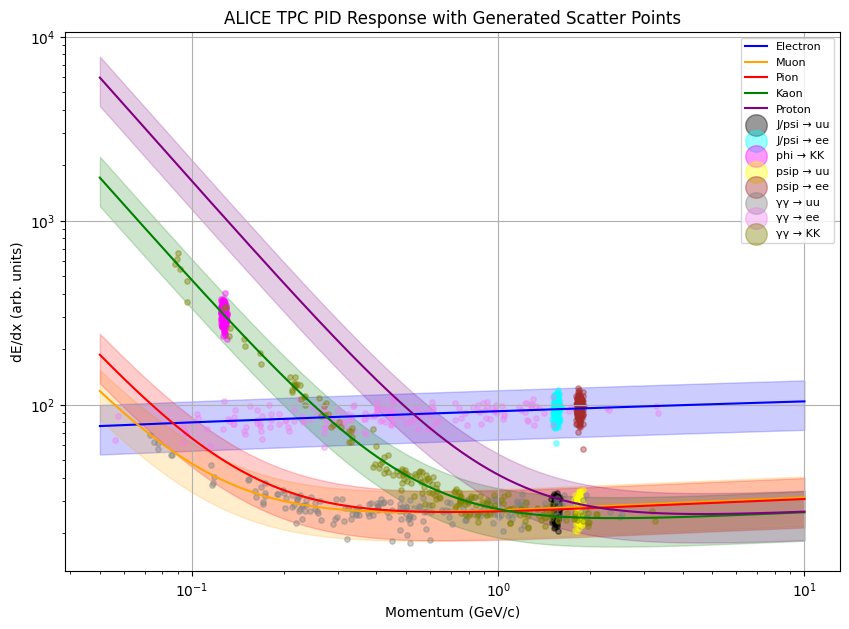

In [39]:
# ============================================================
# REAL DATA SET - NO EXOTICA
# ============================================================

# ============================================================
#  PROCESS DICTIONARY
# ============================================================

processes = {
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "psip → ee": generate_psip_ee,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

vectors_list = []
def generate_scatter_points(generator, momentum_range, N=2000):
    momenta = []
    dEdx_vals = []

    minval = min(momentum_range)
    maxval = max(momentum_range)
    for _ in range(N):
        result = generator()
        if len(result) == 2:
            v1, v2 = result
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)
            vectors_list.append((v1,v2))
            vec_res = (v1,v2)
        
        if len(result) == 3:
            v1, v2, v3 = result
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)
            v3 = smear_event_resolution(v3)
            vectors_list.append((v1,v2,v3))
            vec_res = (v1,v2,v3)
        for v in vec_res:
            E, p, th, ph, m = v
            if p < minval:
                continue
            if p > maxval:
                continue
            particle = particle_type_from_mass(m)
            sf = stretch_factor_for(particle)

            dEdx = gaussian_tpc_response(p, particle, sf)

            momenta.append(p)
            dEdx_vals.append(dEdx)

    return np.array(momenta), np.array(dEdx_vals)


# ============================================================
#  PLOTTER
# ============================================================

def plot_tpc_with_scatter(momenta_range):
    momentum_range = momenta_range

    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(10, 7))

    # PID bands
    for particle, settings in particle_types.items():
        resp, low, up = tpc_pid_response(
            momentum_range, particle.lower(), settings['stretch_factor']
        )
        plt.plot(momentum_range, resp, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, low, up, color=settings['color'], alpha=0.2)

    # Scatter points from generators
    colors = ["black", "cyan", "magenta", "yellow", "brown", "gray", "violet", "olive","red", "blue"]

    for (name, gen), col in zip(processes.items(), colors):
        pvals, dvals = generate_scatter_points(gen, momentum_range, N=100)
        plt.scatter(pvals, dvals, s=15, alpha=0.4, label=name, color=col)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("dE/dx (arb. units)")
    plt.title("ALICE TPC PID Response with Generated Scatter Points")
    plt.legend(markerscale=4, fontsize=8)
    plt.grid(True)
    plt.show()


# ============================================================
#  RUN
# ============================================================
momentum_range = np.linspace(0.05, 10, 2000)
plot_tpc_with_scatter(momentum_range)

In [40]:
df = generate_pid_table()
df.tail()

,EvID,ptype,px,py,pz,p,E,dEdx_meas,nsigma_electron,nsigma_muon,nsigma_pion,nsigma_kaon,nsigma_proton,Invariant mass
1595,797,kaon,-0.035332,-0.479077,0.106107,0.491957,0.696949,42.844828,-5.150329,6.444862,6.268566,0.198626,-5.659092,1.392323
1596,798,kaon,-0.270044,-0.458032,0.694858,0.874954,1.004620,31.354069,-6.567755,1.852396,1.990529,1.031985,-3.360400,1.992836
1597,798,kaon,0.264247,0.448200,-0.679942,0.856172,0.988305,34.119768,-6.260365,2.911996,3.056457,1.892831,-2.934839,1.992836
1598,799,kaon,-0.130126,0.108463,0.198211,0.260738,0.558302,79.551348,-0.644525,18.766490,16.501124,-1.422435,-7.184868,1.118474
1599,799,kaon,0.132120,-0.110124,-0.201247,0.264733,0.560179,103.797157,2.195472,27.654010,24.778532,1.449024,-6.226938,1.118474


In [41]:
candidate_df = generate_event_candidate_table(df)
candidate_df.tail()

,EvID,N Electron candidates,N Muon candidates,N Pion candidates,N Kaon candidates,N Proton candidates,N Tracks,Invariant Mass
795,795,0,2,2,2,0,2,2.317141
796,796,0,0,0,0,0,2,1.486178
797,797,0,0,0,1,0,2,1.392323
798,798,0,0,0,0,0,2,1.992836
799,799,0,0,0,0,0,2,1.118474


In [42]:
# ============================================================
# SAVE AS CSV DATASET
# ============================================================

candidate_df.to_csv(
    "event_candidate_dataset_real-noexotica.csv",
    index=False
)

print("Saved CSV dataset: event_candidate_dataset_real-noexotica.csv")

# ============================================================
# SAVE AS PLAIN TEXT FILE
# ============================================================

with open("event_candidate_dataset_real-noexotica.txt", "w") as f:

    f.write("ALICE TPC PID EVENT CANDIDATE TABLE\n")
    f.write("=" * 80 + "\n\n")

    f.write(candidate_df.to_string(index=False))

print("Saved text dataset: event_candidate_dataset_real-noexotica.txt")

Saved CSV dataset: event_candidate_dataset_real-noexotica.csv
Saved text dataset: event_candidate_dataset_real-noexotica.txt
